# 4. Cross-Dataset County Summary

In [1]:
%run 00_shared.py

## Load processed data

In [2]:
_pop  = pd.read_pickle(f"{DATA_PROCESSED}/population.pkl")
_race = pd.read_pickle(f"{DATA_PROCESSED}/race_ethnicity.pkl")
_hous = pd.read_pickle(f"{DATA_PROCESSED}/housing.pkl")

pop_counties     = _pop["pop_counties"]
diversity        = _race["diversity"]
housing_counties = _hous["housing_counties"]
state_vac        = _hous["state_vac"]

## 4a. Merge County-Level Summary

In [3]:
summary = (
    pop_counties[["Place", "2020 Total Population", "2010 Total Population", "Percent Change"]]
    .rename(columns={"Place": "County", "Percent Change": "pop_pct_change"})
    .assign(County_Short=lambda df: df["County"].str.replace(" County", "", regex=False))
    .merge(
        diversity[["County_Short", "pct_nonwhite", "pct_hispanic"]],
        on="County_Short", how="left"
    )
    .drop(columns="County_Short")
    .merge(
        housing_counties[["Geography", "Total", "vacancy_rate"]]
        .rename(columns={"Geography": "County", "Total": "housing_units"}),
        on="County", how="left"
    )
)

summary["housing_per_capita"]  = summary["housing_units"] / summary["2020 Total Population"]
summary["pop_pct_change_pct"]  = summary["pop_pct_change"] * 100

display(summary[["County", "2020 Total Population", "pop_pct_change_pct",
                  "pct_nonwhite", "pct_hispanic", "housing_units", "vacancy_rate", "housing_per_capita"]]
        .rename(columns={
            "2020 Total Population": "Pop 2020",
            "pop_pct_change_pct":    "Pop Chg %",
            "pct_nonwhite":          "% Non-White",
            "pct_hispanic":          "% Hispanic",
            "housing_units":         "Housing Units",
            "vacancy_rate":          "Vacancy %",
            "housing_per_capita":    "Units/Person",
        })
        .sort_values("Pop 2020", ascending=False)
        .reset_index(drop=True)
)

,County,Pop 2020,Pop Chg %,% Non-White,% Hispanic,Housing Units,Vacancy %,Units/Person
0,Cumberland County,303069,7.6,13.5,2.6,149452,14.3,0.5
1,York County,211972,7.5,8.5,1.9,112198,20.7,0.5
2,Penobscot County,152199,-1.1,9.1,1.8,74878,14.2,0.5
3,Kennebec County,123642,1.2,8.9,2.1,62607,15.0,0.5
4,Androscoggin County,111139,3.2,13.7,2.0,49837,8.9,0.4
5,Aroostook County,67105,-6.6,7.4,1.4,38303,22.2,0.6
6,Oxford County,57777,-0.1,7.5,1.5,36130,31.6,0.6
7,Hancock County,55478,1.9,7.9,1.7,40133,37.8,0.7
8,Somerset County,50477,-3.4,7.1,1.3,29785,26.4,0.6
9,Knox County,40607,2.2,7.6,1.7,24255,26.3,0.6


## 4b. Scatter Plots

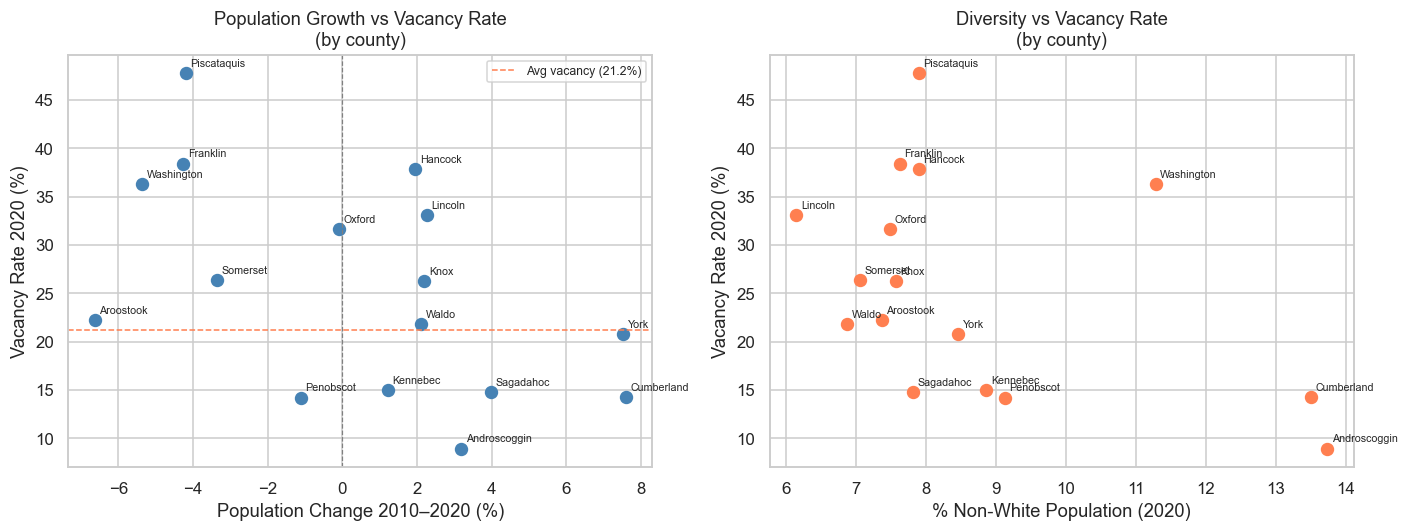

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(summary["pop_pct_change_pct"], summary["vacancy_rate"], s=60, color="steelblue")
for _, row in summary.iterrows():
    ax.annotate(row["County"].replace(" County",""), (row["pop_pct_change_pct"], row["vacancy_rate"]),
                fontsize=7, ha="left", va="bottom", xytext=(3, 3), textcoords="offset points")
ax.axhline(state_vac, color="coral", linestyle="--", linewidth=1,
           label=f"Avg vacancy ({state_vac:.1f}%)")
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("Population Change 2010\u20132020 (%)")
ax.set_ylabel("Vacancy Rate 2020 (%)")
ax.set_title("Population Growth vs Vacancy Rate\n(by county)")
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.scatter(summary["pct_nonwhite"], summary["vacancy_rate"], s=60, color="coral")
for _, row in summary.iterrows():
    ax2.annotate(row["County"].replace(" County",""), (row["pct_nonwhite"], row["vacancy_rate"]),
                 fontsize=7, ha="left", va="bottom", xytext=(3, 3), textcoords="offset points")
ax2.set_xlabel("% Non-White Population (2020)")
ax2.set_ylabel("Vacancy Rate 2020 (%)")
ax2.set_title("Diversity vs Vacancy Rate\n(by county)")

plt.tight_layout()
plt.show()